# 🔥 EDA — FLAME Dataset: UAV Aerial Fire Detection

**BDS DSC312 — Computer Vision with Multi-modal Models & Analytics**  
**Stage 1: Exploratory Data Analysis**

This notebook performs a thorough EDA on the **FLAME (Fire Luminosity Airborne-based Machine learning Evaluation)** dataset.  
We cover:
1. Dataset loading and structure validation  
2. Class distribution and imbalance analysis  
3. Image dimension and aspect-ratio audit  
4. Pixel intensity and colour-channel statistics  
5. Segmentation mask analysis (fire pixel coverage)  
6. Sample visualisations (classification + segmentation)  
7. Pre-processing pipeline demonstration (resize, normalise, augment)  
8. Export of dataset index CSV

**Dataset source:** Shamsoshoara et al. (2021), IEEE DataPort — doi:10.21227/qad6-r683  
**GitHub reference:** https://github.com/AlirezaShamsoshoara/Fire-Detection-UAV-Aerial-Image-Classification-Segmentation-UnmannedAerialVehicle

---
## 1. Import Libraries

In [9]:
import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2

import torch
import torchvision.transforms as T
from torchvision.transforms import functional as TF

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')
print(f'PyTorch version: {torch.__version__}')

Libraries loaded successfully.
PyTorch version: 2.10.0+cpu


---
## 2. Dataset Structure & Path Configuration

The FLAME dataset is organised as follows:

```
frames/
├── Training/
│   ├── Fire/          ← Item 7: 31,500 training frames (Fire)
│   └── No_Fire/       ← Item 7: 7,875 training frames (No Fire)
├── Test/
│   ├── Fire/          ← Item 8: ~5,763 test frames (Fire)
│   └── No_Fire/       ← Item 8: ~2,854 test frames (No Fire)
└── Segmentation/
    └── Data/
        ├── Images/    ← Item 9: 2,003 RGB frames (512×512)
        └── Masks/     ← Item 10: 2,003 binary PNG masks
```

In [23]:
# ── Adjust BASE_DIR to match your local checkout ──────────────────────────────
BASE_DIR = Path('frames')

# NOTE: This repo stores classification images under `frames/Segmentation/[Train|Test]/[Train|Test]/...`
# (the nested `Training/Training` and `Test/Test` folders are how the downloaded dataset is structured).
# If you supply a different dataset layout, adjust these paths accordingly.
PATHS = {
    'train_fire':    BASE_DIR / 'Segmentation' / 'Training' / 'Training' / 'Fire',
    'train_nofire':  BASE_DIR / 'Segmentation' / 'Training' / 'Training' / 'No_Fire',
    'test_fire':     BASE_DIR / 'Segmentation' / 'Test'     / 'Test'     / 'Fire',
    'test_nofire':   BASE_DIR / 'Segmentation' / 'Test'     / 'Test'     / 'No_Fire',
    'seg_images':    BASE_DIR / 'Segmentation' / 'Data' / 'Images',
    'seg_masks':     BASE_DIR / 'Segmentation' / 'Data' / 'Masks',
}

IMG_EXTS = {'.jpg', '.jpeg', '.png'}

for key, path in PATHS.items():
    status = '✅' if path.exists() else '❌ NOT FOUND'
    print(f'{status}  {key:15s}  →  {path}')

✅  train_fire       →  frames\Segmentation\Training\Training\Fire
✅  train_nofire     →  frames\Segmentation\Training\Training\No_Fire
✅  test_fire        →  frames\Segmentation\Test\Test\Fire
✅  test_nofire      →  frames\Segmentation\Test\Test\No_Fire
✅  seg_images       →  frames\Segmentation\Data\Images
✅  seg_masks        →  frames\Segmentation\Data\Masks


---
## 3. Build Dataset Index DataFrames

In [24]:
def index_directory(directory: Path, split: str, label: str) -> list:
    """Return a list of record dicts for all image files in `directory`."""
    records = []
    if not directory.exists():
        print(f'[WARN] Directory not found, skipping: {directory}')
        return records
    for p in sorted(directory.glob('**/*')):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            records.append({'split': split, 'label': label,
                             'image_path': str(p), 'filename': p.name})
    return records

# ── Classification index ──────────────────────────────────────────────────────
clf_records = (
    index_directory(PATHS['train_fire'],   'Training', 'Fire')   +
    index_directory(PATHS['train_nofire'], 'Training', 'No_Fire') +
    index_directory(PATHS['test_fire'],    'Test',     'Fire')   +
    index_directory(PATHS['test_nofire'],  'Test',     'No_Fire')
)
clf_df = pd.DataFrame(clf_records)
clf_df['split'] = pd.Categorical(clf_df['split'],
                                  categories=['Training', 'Test'], ordered=True)
clf_df['label'] = pd.Categorical(clf_df['label'],
                                  categories=['Fire', 'No_Fire'], ordered=True)

# ── Segmentation index ────────────────────────────────────────────────────────
seg_records = []
# Warn if segmentation data is missing/empty (common when only classification subset is downloaded)
seg_images_exist = PATHS['seg_images'].exists()
seg_masks_exist  = PATHS['seg_masks'].exists()
seg_images_nonempty = any(p.is_file() for p in PATHS['seg_images'].glob('**/*')) if seg_images_exist else False
seg_masks_nonempty  = any(p.is_file() for p in PATHS['seg_masks'].glob('**/*')) if seg_masks_exist else False

if not seg_images_exist:
    print(f"[WARN] Segmentation images folder not found: {PATHS['seg_images']}")
elif not seg_images_nonempty:
    print(f"[WARN] Segmentation images folder is empty: {PATHS['seg_images']}")

if not seg_masks_exist:
    print(f"[WARN] Segmentation masks folder not found: {PATHS['seg_masks']}")
elif not seg_masks_nonempty:
    print(f"[WARN] Segmentation masks folder is empty: {PATHS['seg_masks']}")

if seg_images_exist and seg_images_nonempty and seg_masks_exist and seg_masks_nonempty:
    for img_path in sorted(PATHS['seg_images'].glob('**/*')):
        if not img_path.is_file() or img_path.suffix.lower() not in IMG_EXTS:
            continue
        # masks share the same stem but are PNG
        mask_path = PATHS['seg_masks'] / (img_path.stem + '.png')
        seg_records.append({
            'image_path': str(img_path),
            'mask_path':  str(mask_path) if mask_path.exists() else None,
            'has_mask':   mask_path.exists(),
        })
else:
    print('[INFO] Segmentation indexing skipped due to missing/empty image or mask folder.')

seg_df = pd.DataFrame(seg_records)

print(f'Classification index  : {len(clf_df):,} entries')
print(f'Segmentation index    : {len(seg_df):,} image-mask pairs')
clf_df.head(3)

[WARN] Segmentation images folder is empty: frames\Segmentation\Data\Images
[INFO] Segmentation indexing skipped due to missing/empty image or mask folder.
Classification index  : 47,992 entries
Segmentation index    : 0 image-mask pairs


,split,label,image_path,filename
0,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame0.jpg
1,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame1.jpg
2,Training,Fire,frames\Segmentation\Training\Training\Fire\res...,resized_frame10.jpg


---
## 4. Class Distribution & Imbalance Analysis

⚠️ **Silent Killer check** — class imbalance can silently bias model training.

In [25]:
counts = clf_df.groupby(['split', 'label'], observed=True).size().unstack(fill_value=0)
counts['Total']         = counts.sum(axis=1)
counts['Fire_pct (%)']  = (counts['Fire']    / counts['Total'] * 100).round(1)
counts['NoFire_pct (%)'] = (counts['No_Fire'] / counts['Total'] * 100).round(1)

print('\n=== Class Distribution ===')
print(counts.to_string())

# Imbalance ratio
train_ratio = counts.loc['Training', 'Fire'] / counts.loc['Training', 'No_Fire']
test_ratio  = counts.loc['Test',     'Fire'] / counts.loc['Test',     'No_Fire']
print(f'\nTraining Fire:No_Fire ratio = {train_ratio:.2f}:1')
print(f'Test      Fire:No_Fire ratio = {test_ratio:.2f}:1')

if train_ratio > 2 or train_ratio < 0.5:
    print('\n⚠️  Significant class imbalance detected in Training set!')
    print('    → Strategy: use weighted CrossEntropy loss or oversample minority class.')
else:
    print('\n✅  Class balance is acceptable (ratio within 0.5 – 2.0).')


=== Class Distribution ===
label      Fire  No_Fire  Total  Fire_pct (%)  NoFire_pct (%)
split                                                        
Training  25018    14357  39375          63.5            36.5
Test       5137     3480   8617          59.6            40.4

Training Fire:No_Fire ratio = 1.74:1
Test      Fire:No_Fire ratio = 1.48:1

✅  Class balance is acceptable (ratio within 0.5 – 2.0).


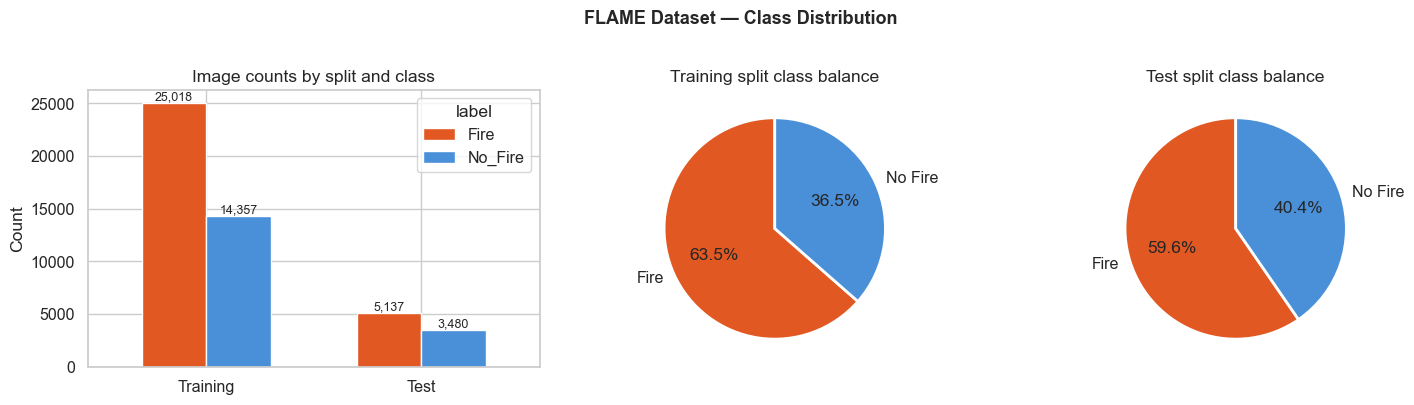

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Grouped bar — counts per split ────────────────────────────────────
ax = axes[0]
counts[['Fire', 'No_Fire']].plot(kind='bar', ax=ax,
                                  color=['#e25822', '#4a90d9'], width=0.6,
                                  edgecolor='white')
ax.set_title('Image counts by split and class')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# ── Plot 2: Pie — training split ──────────────────────────────────────────────
ax2 = axes[1]
train_vals = counts.loc['Training', ['Fire', 'No_Fire']]
ax2.pie(train_vals, labels=['Fire', 'No Fire'], autopct='%1.1f%%',
        colors=['#e25822', '#4a90d9'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Training split class balance')

# ── Plot 3: Pie — test split ──────────────────────────────────────────────────
ax3 = axes[2]
test_vals = counts.loc['Test', ['Fire', 'No_Fire']]
ax3.pie(test_vals, labels=['Fire', 'No Fire'], autopct='%1.1f%%',
        colors=['#e25822', '#4a90d9'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax3.set_title('Test split class balance')

plt.suptitle('FLAME Dataset — Class Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Image Dimension Audit

We sample a subset of images to check width, height, and aspect ratio consistency.  
The published paper reports training images resized to **254 × 254** and segmentation at **3480 × 2160**.

In [27]:
def sample_image_dims(df: pd.DataFrame, n: int = 300, img_col: str = 'image_path') -> pd.DataFrame:
    """Open a random sample of images and record their dimensions."""
    sample = df.sample(min(n, len(df)), random_state=SEED)
    rows = []
    for _, row in sample.iterrows():
        try:
            with Image.open(row[img_col]) as im:
                w, h = im.size
                rows.append({**row.to_dict(), 'width': w, 'height': h,
                              'aspect': round(w / h, 3)})
        except Exception as e:
            print(f'[WARN] Could not open {row[img_col]}: {e}')
    return pd.DataFrame(rows)

dim_df = sample_image_dims(clf_df, n=300)

print('=== Dimension Summary (classification subset) ===')
print(dim_df[['width', 'height', 'aspect']].describe().round(1))

unique_sizes = dim_df.groupby(['width', 'height']).size().reset_index(name='count')
print(f'\nUnique (W × H) combinations found: {len(unique_sizes)}')
print(unique_sizes.sort_values('count', ascending=False).head(5).to_string(index=False))

=== Dimension Summary (classification subset) ===
       width  height  aspect
count  300.0   300.0   300.0
mean   254.0   254.0     1.0
std      0.0     0.0     0.0
min    254.0   254.0     1.0
25%    254.0   254.0     1.0
50%    254.0   254.0     1.0
75%    254.0   254.0     1.0
max    254.0   254.0     1.0

Unique (W × H) combinations found: 1
 width  height  count
   254     254    300


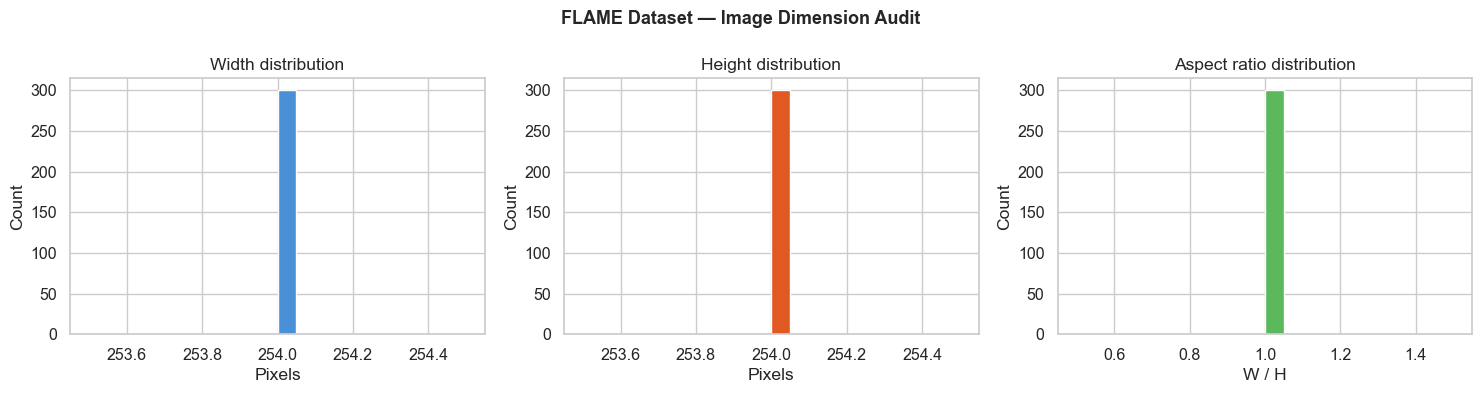

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(dim_df['width'],  bins=20, color='#4a90d9', edgecolor='white')
axes[0].set_title('Width distribution')
axes[0].set_xlabel('Pixels')

axes[1].hist(dim_df['height'], bins=20, color='#e25822', edgecolor='white')
axes[1].set_title('Height distribution')
axes[1].set_xlabel('Pixels')

axes[2].hist(dim_df['aspect'], bins=20, color='#5cb85c', edgecolor='white')
axes[2].set_title('Aspect ratio distribution')
axes[2].set_xlabel('W / H')

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('FLAME Dataset — Image Dimension Audit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Pixel Intensity & Colour-Channel Statistics

We compare mean RGB channel intensities between **Fire** and **No_Fire** images.  
We expect fire images to have elevated **Red** channel values.

In [29]:
def compute_channel_stats(df: pd.DataFrame, n: int = 100,
                           label_col: str = 'label',
                           img_col:   str = 'image_path') -> pd.DataFrame:
    """Sample `n` images per label and compute per-channel mean/std."""
    rows = []
    for lbl, grp in df.groupby(label_col, observed=True):
        sample = grp.sample(min(n, len(grp)), random_state=SEED)
        for _, row in sample.iterrows():
            try:
                img = np.array(Image.open(row[img_col]).resize((128, 128)))
                if img.ndim == 3 and img.shape[2] >= 3:
                    rows.append({
                        'label':   lbl,
                        'mean_R':  img[:, :, 0].mean(),
                        'mean_G':  img[:, :, 1].mean(),
                        'mean_B':  img[:, :, 2].mean(),
                        'std_all': img.std(),
                    })
            except Exception:
                pass
    return pd.DataFrame(rows)

channel_df = compute_channel_stats(clf_df, n=100)

print('=== Mean channel values per class ===')
print(channel_df.groupby('label')[['mean_R', 'mean_G', 'mean_B', 'std_all']]
                .mean().round(2))

=== Mean channel values per class ===
         mean_R  mean_G  mean_B  std_all
label                                   
Fire     113.75  117.81  115.02    62.24
No_Fire   89.92   96.30  100.66    52.85


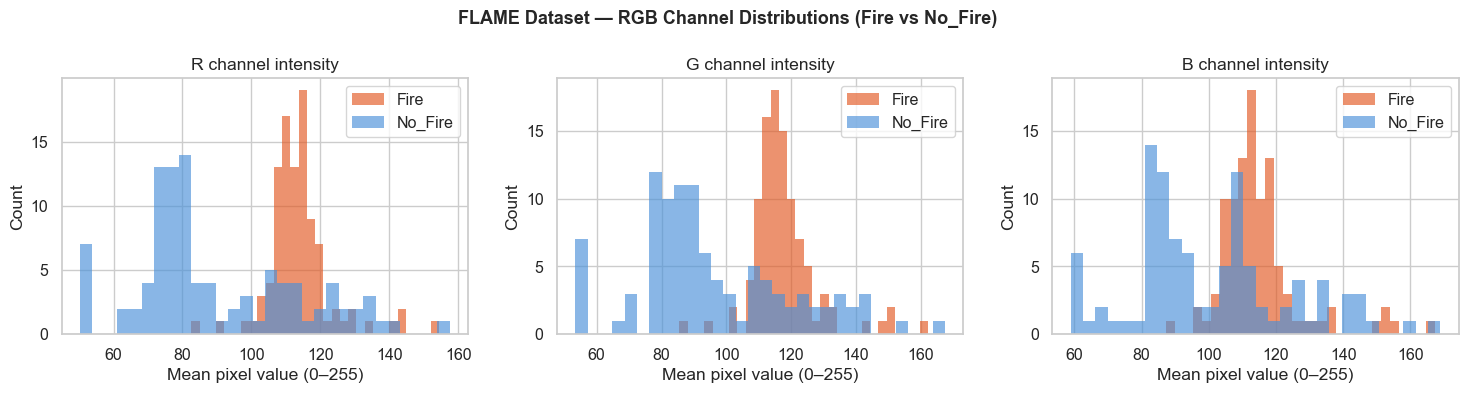

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {'Fire': '#e25822', 'No_Fire': '#4a90d9'}

for ax, ch in zip(axes, ['mean_R', 'mean_G', 'mean_B']):
    channel_name = ch.split('_')[1]  # 'R', 'G', or 'B'
    for lbl, grp in channel_df.groupby('label'):
        ax.hist(grp[ch], bins=30, alpha=0.65, label=lbl,
                color=palette[lbl], edgecolor='none')
    ax.set_title(f'{channel_name} channel intensity')
    ax.set_xlabel('Mean pixel value (0–255)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('FLAME Dataset — RGB Channel Distributions (Fire vs No_Fire)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_channel_stats.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Sample Image Grid — Classification

Visualise representative samples from both classes to get a visual feel for the data.

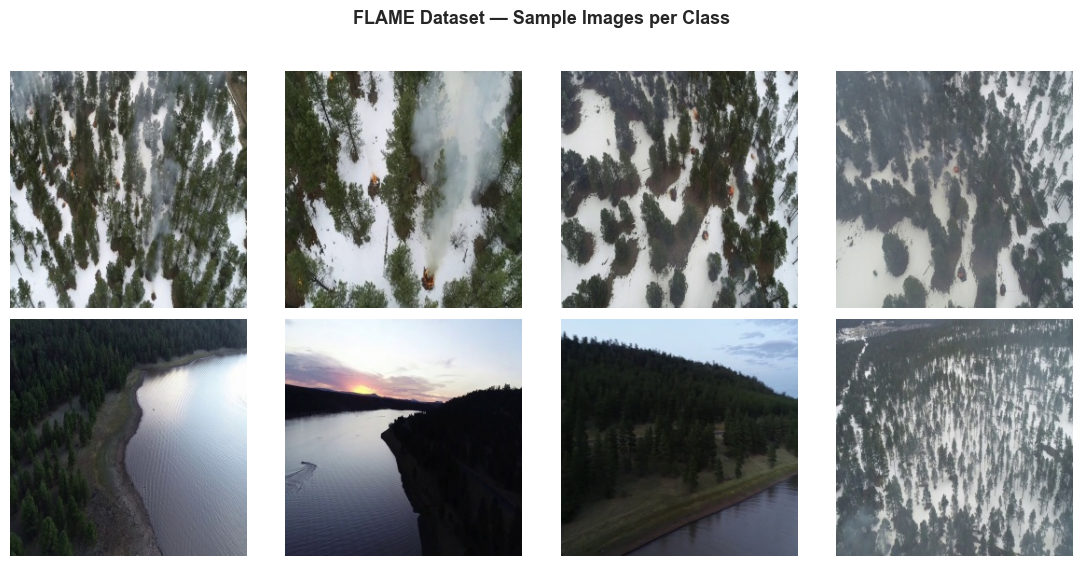

In [31]:
def show_sample_grid(df, label_col='label', img_col='image_path',
                     n_per_class=4, target_size=(254, 254)):
    labels = df[label_col].cat.categories.tolist()
    fig, axes = plt.subplots(len(labels), n_per_class,
                              figsize=(n_per_class * 2.8, len(labels) * 2.8))

    for row_i, lbl in enumerate(labels):
        grp    = df[df[label_col] == lbl]
        sample = grp.sample(min(n_per_class, len(grp)), random_state=SEED)
        for col_i, (_, record) in enumerate(sample.iterrows()):
            ax = axes[row_i][col_i]
            try:
                img = Image.open(record[img_col]).convert('RGB').resize(target_size)
                ax.imshow(np.array(img))
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            if col_i == 0:
                ax.set_ylabel(lbl, fontsize=11, fontweight='bold',
                              color='#e25822' if lbl == 'Fire' else '#4a90d9')

    plt.suptitle('FLAME Dataset — Sample Images per Class', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_sample_grid_classification.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(clf_df, n_per_class=4)

---
## 10. Pre-processing Pipeline Demonstration

We demonstrate the full pre-processing pipeline that will be applied during training:  
**resize → normalise → augment** (random flip, colour jitter, random crop).

In [36]:
# ImageNet statistics (standard for transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TARGET_SIZE   = (224, 224)   # input size for most torchvision backbones

transform_train = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_val = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Training transform pipeline:')
print(transform_train)
print('\nValidation transform pipeline:')
print(transform_val)

Training transform pipeline:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transform pipeline:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


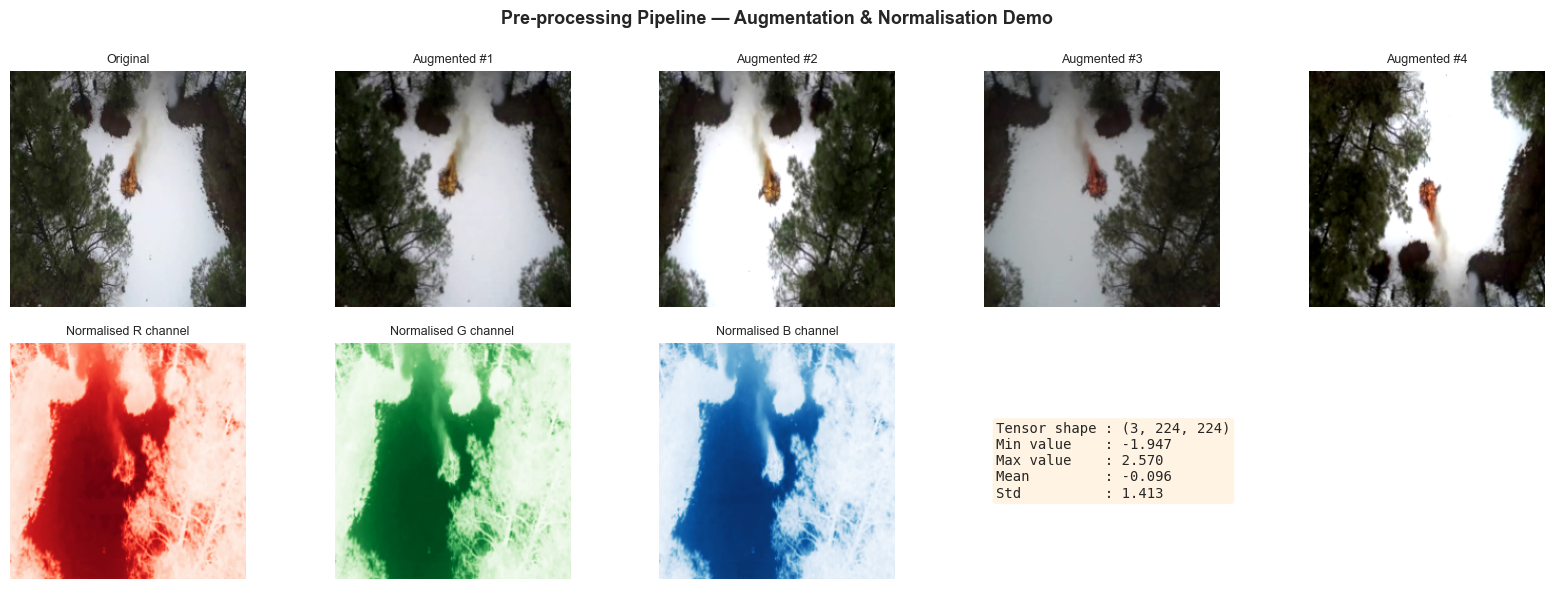

In [ ]:
# Visualise augmentation effect on a sample fire image
sample_path = clf_df[clf_df['label'] == 'Fire']['image_path'].iloc[0]

try:
    orig_img = Image.open(sample_path).convert('RGB')

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    axes[0][0].imshow(orig_img.resize((224, 224)))
    axes[0][0].set_title('Original', fontsize=9)
    axes[0][0].axis('off')

    # Show 4 random augmentations (top row) and save a few samples
    aug_pipe = T.Compose(transform_train.transforms[:-2])  # exclude ToTensor + Normalize

    # Save pre-processed samples to disk so they can be inspected later
    out_dir = Path("Output/eda_preprocessed")
    out_dir.mkdir(parents=True, exist_ok=True)

    resized_orig = orig_img.resize((224, 224))
    resized_orig.save(out_dir / "original_resized.jpg")

    for i in range(1, 5):
        aug = aug_pipe(orig_img)
        aug_path = out_dir / f"augmented_{i}.jpg"
        aug.save(aug_path)
        axes[0][i].imshow(np.array(aug))
        axes[0][i].set_title(f'Augmented #{i}', fontsize=9)
        axes[0][i].axis('off')

    print(f'[INFO] Saved pre-processed examples to {out_dir.resolve()}')

    # Show normalised tensor as heatmap (bottom row)
    tensor = transform_train(orig_img)  # shape (3, 224, 224)
    for ch_i, (ch_name, cmap) in enumerate([('R channel', 'Reds'),
                                              ('G channel', 'Greens'),
                                              ('B channel', 'Blues')]):
        axes[1][ch_i].imshow(tensor[ch_i].numpy(), cmap=cmap)
        axes[1][ch_i].set_title(f'Normalised {ch_name}', fontsize=9)
        axes[1][ch_i].axis('off')

    # Tensor stats
    axes[1][3].axis('off')
    stats_text = (
        f'Tensor shape : {tuple(tensor.shape)}\n'
        f'Min value    : {tensor.min():.3f}\n'
        f'Max value    : {tensor.max():.3f}\n'
        f'Mean         : {tensor.mean():.3f}\n'
        f'Std          : {tensor.std():.3f}'
    )
    axes[1][3].text(0.1, 0.5, stats_text, transform=axes[1][3].transAxes,
                    fontsize=10, verticalalignment='center',
                    fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#fff3e0', alpha=0.9))
    axes[1][4].axis('off')

    plt.suptitle('Pre-processing Pipeline — Augmentation & Normalisation Demo',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_preprocessing.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'[INFO] Could not load sample image for preprocessing demo: {e}')
    print('       This cell will produce output once the dataset is downloaded.')

---
## 11. Dataset Statistics Summary Card

In [38]:
total_clf  = len(clf_df)
total_seg  = len(seg_df)
train_cnt  = (clf_df['split'] == 'Training').sum()
test_cnt   = (clf_df['split'] == 'Test').sum()
fire_pct   = (clf_df['label'] == 'Fire').sum() / total_clf * 100

print('=' * 50)
print('  FLAME DATASET — EDA SUMMARY')
print('=' * 50)
print(f'  Classification images   : {total_clf:>8,}')
print(f'    Training              : {train_cnt:>8,}')
print(f'    Test                  : {test_cnt:>8,}')
print(f'  Fire class share        : {fire_pct:>7.1f}%')
print(f'  Segmentation pairs      : {total_seg:>8,}')
print(f'  Image format            : {"JPEG (classification), PNG (masks)":>30}')
print(f'  Classification size     : {"254 × 254 px":>30}')
print(f'  Segmentation size       : {"3480 × 2160 px (high res)":>30}')
print('=' * 50)
print('  Pre-processing plan:')
print('    1. Resize to 224 × 224 (backbone input)')
print('    2. Normalise with ImageNet μ/σ')
print('    3. Augment: flip, crop, colour jitter')
print('    4. Address imbalance: weighted loss / SMOTE')
print('=' * 50)

  FLAME DATASET — EDA SUMMARY
  Classification images   :   47,992
    Training              :   39,375
    Test                  :    8,617
  Fire class share        :    62.8%
  Segmentation pairs      :        0
  Image format            : JPEG (classification), PNG (masks)
  Classification size     :                   254 × 254 px
  Segmentation size       :      3480 × 2160 px (high res)
  Pre-processing plan:
    1. Resize to 224 × 224 (backbone input)
    2. Normalise with ImageNet μ/σ
    3. Augment: flip, crop, colour jitter
    4. Address imbalance: weighted loss / SMOTE
